# import packages

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import math
from windrose import WindroseAxes

# Loading the data

In [39]:
import pandas as pd

path = "../data/togo-dapaong_qc.csv"

# If it's a CSV:
df = pd.read_csv(path)
print("Dataset shape (rows, columns):")
print(df.shape)


Dataset shape (rows, columns):
(525600, 19)


# 1. Summary Statistics & Missing-Value Report

In [ ]:
print("An overview of the dataset: the first 5 rows")
df.head()

In [ ]:
print("An overview of the dataset: the last 5 rows")
df.tail()

In [40]:
print("An overview of the dataset: a random sample of 5 rows")
df.sample(5)

An overview of the dataset: a random sample of 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
10912,2021-11-01 13:53,808.0,544.0,418.9,846.8,818.0,33.1,49.0,2.1,2.6,0.4,20.7,15.0,976,0,0.0,56.3,56.1,NaN
519729,2022-10-20 22:10,-2.6,0.0,0.0,0.0,0.0,25.2,75.1,1.6,1.9,0.3,225.1,2.5,977,0,0.0,23.1,22.6,NaN
194349,2022-03-08 23:10,-4.0,0.0,0.0,0.0,0.0,29.9,11.7,2.6,3.4,0.4,31.9,10.9,973,0,0.0,29.0,28.7,NaN
296423,2022-05-18 20:24,-1.3,0.0,0.0,0.0,0.0,24.2,84.7,3.7,4.4,0.6,75.6,11.1,977,0,0.0,24.9,24.7,NaN
387180,2022-07-20 21:01,-2.2,0.0,0.0,0.0,0.0,25.4,81.7,1.6,2.4,0.6,216.3,11.2,977,0,0.0,24.5,24.1,NaN


In [41]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600

In [42]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       0.000

In [43]:
print("Check for missing values:")
print(df.isna().sum())

Check for missing values:
Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [44]:
null_percentage = df.isna().mean() * 100
print("Percentage of nulls in each column:")
print(null_percentage)
print("*" * 30)

print("Columns with >5% nulls (percent nulls):")
columns_with_over_5 = null_percentage[null_percentage > 5].sort_values(ascending=False)
if columns_with_over_5.empty:
    print("No columns with >5% nulls")
else:
    print("=============================")
    print(columns_with_over_5)
    print("=============================")

Percentage of nulls in each column:
Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64
******************************
Columns with >5% nulls (percent nulls):
Comments    100.0
dtype: float64


In [45]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


## 1.1 Univariate Analysis

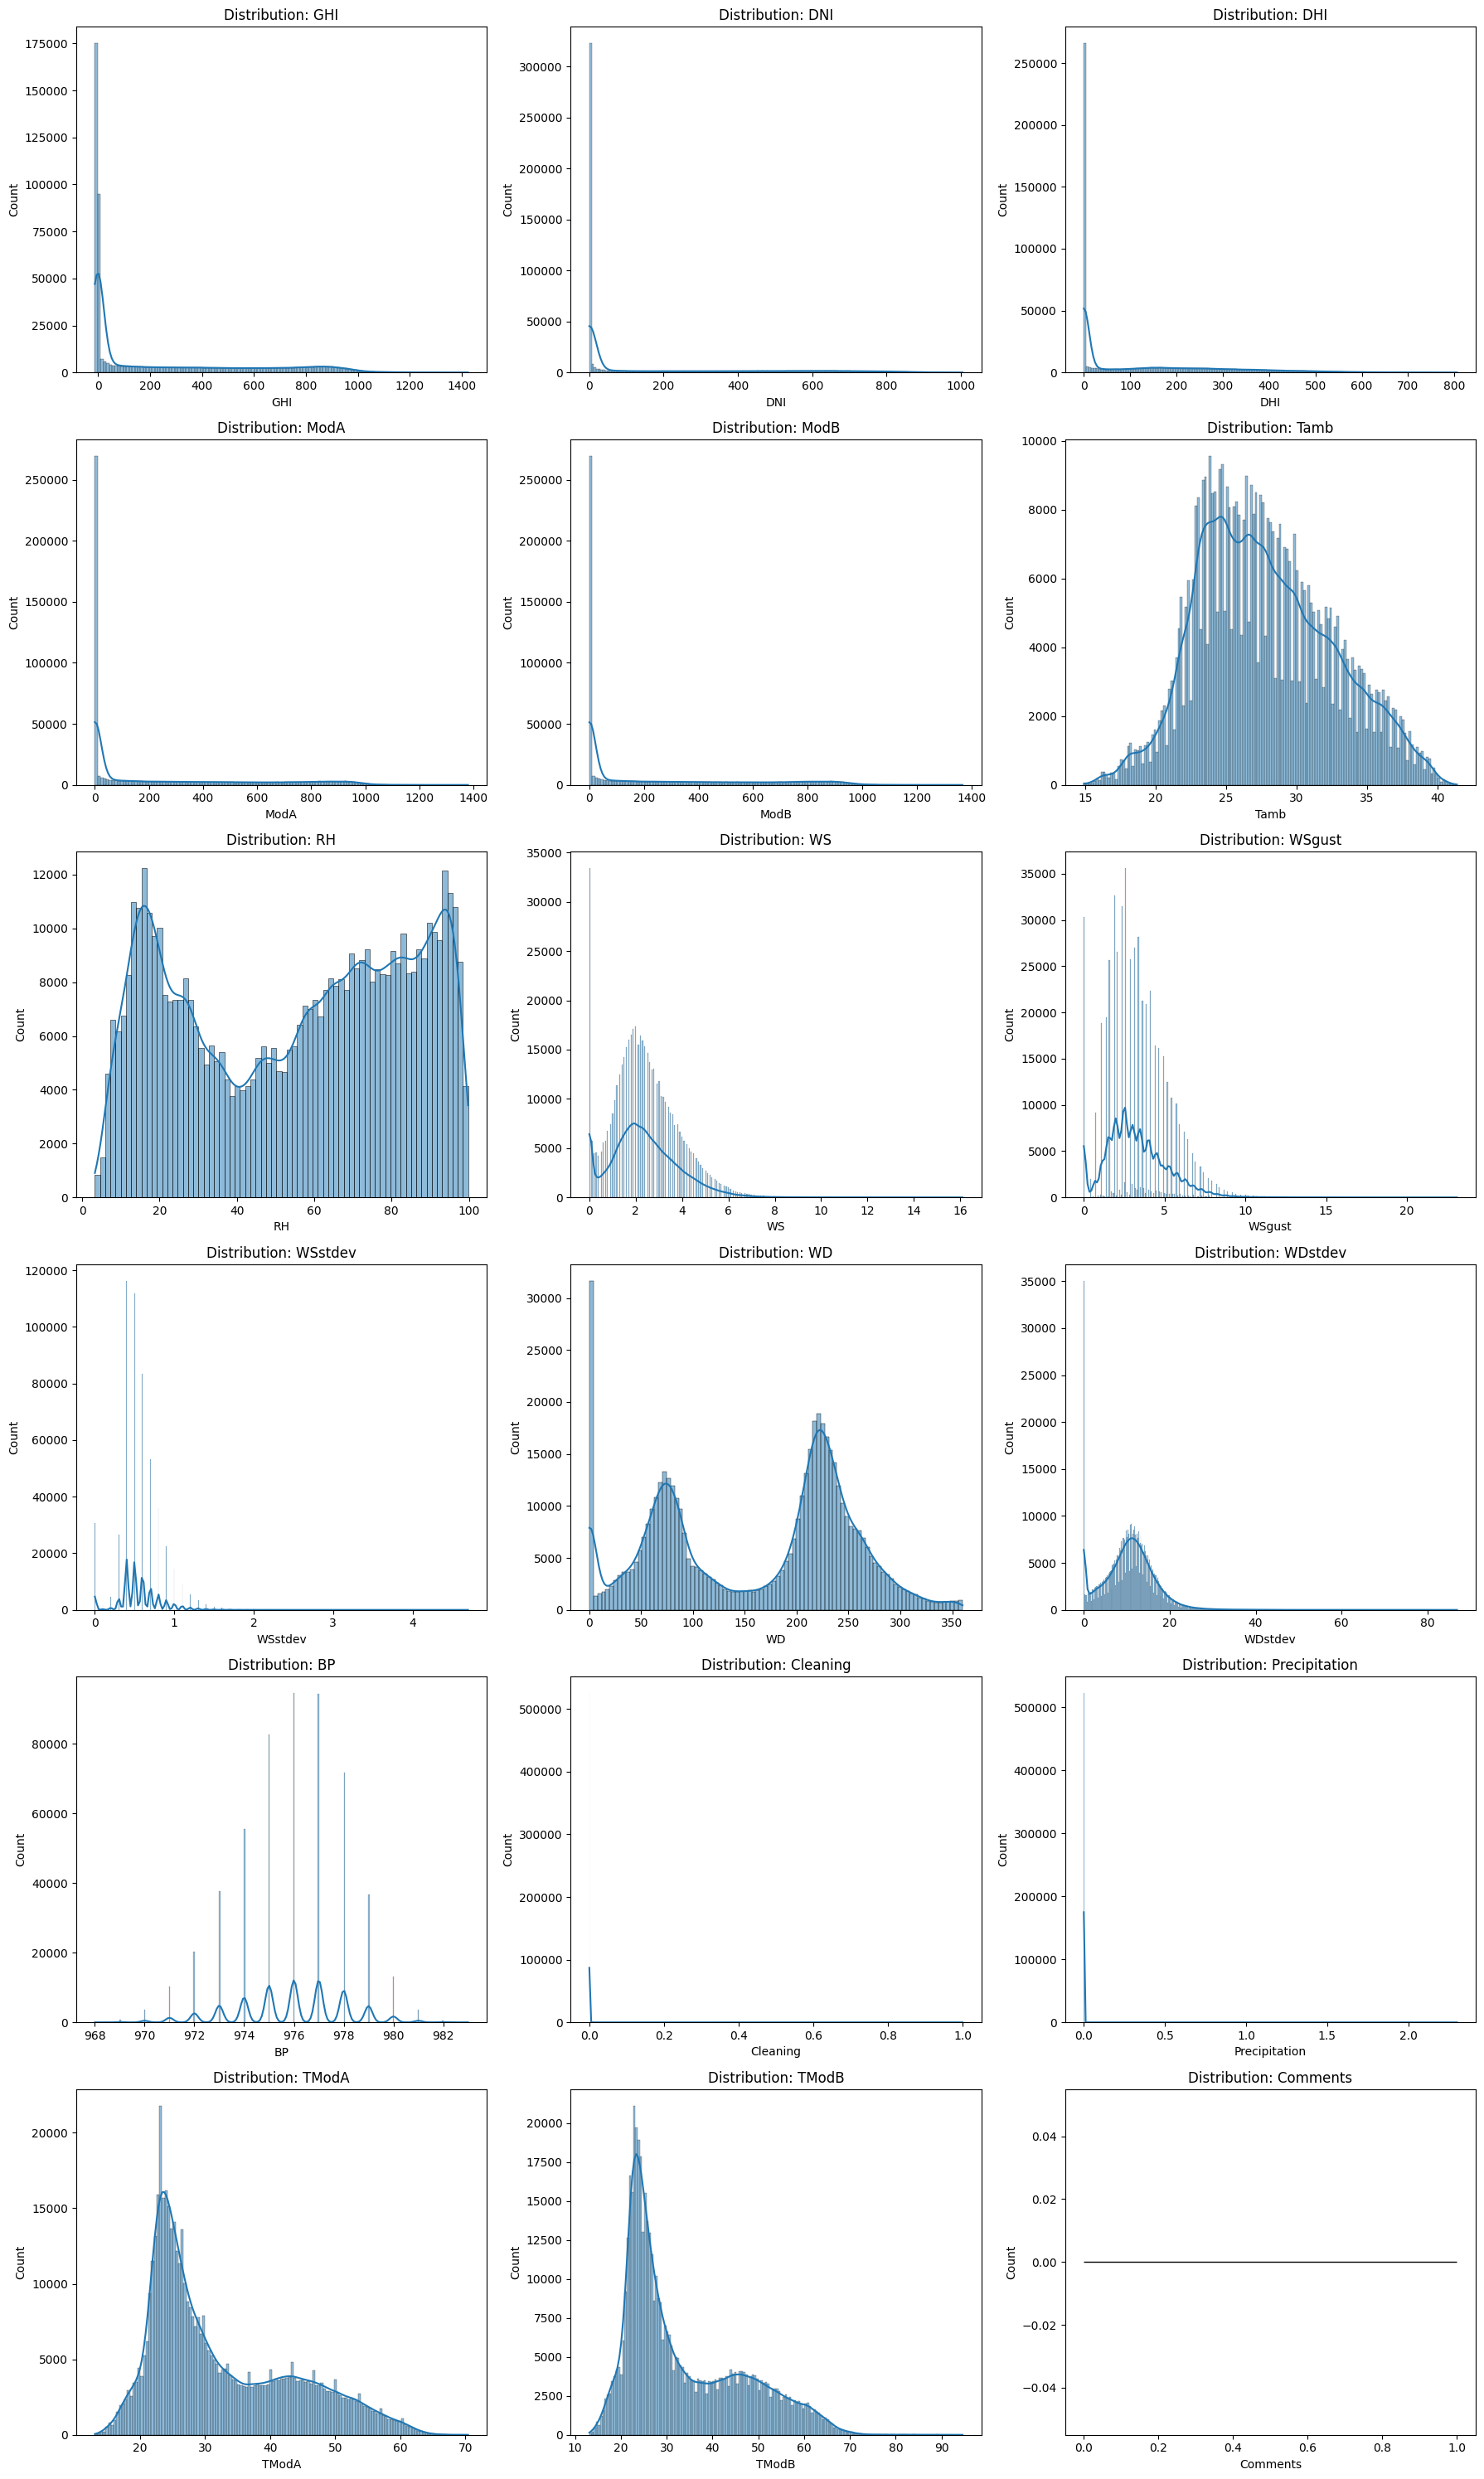

In [46]:
# 1. Get numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Calculate grid dimensions
n_plots = len(num_cols)
# Determine the number of rows needed (3 plots per row)
n_rows = math.ceil(n_plots / 3) 

# 3. Create a single figure with the calculated grid (3 columns wide)
# figsize=(18, ...) ensures the plots are wide enough to be readable
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))

# Flatten the axes array to easily iterate over all subplot locations
axes = axes.flatten()

# 4. Loop and plot each column onto its assigned axis (Histograms: 3 per row)
for i, c in enumerate(num_cols):
    ax = axes[i] # Get the current axis object
    
    # Plot the histogram directly onto the current axis (ax)
    sns.histplot(df[c], kde=True, ax=ax)
    
    ax.set_title(f"Distribution: {c}", fontsize=12)
    ax.set_xlabel(c, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

# 5. Hide any unused subplots
# This handles cases where n_plots is not a perfect multiple of 3 (e.g., 4, 5, 7, 8 columns)
for j in range(n_plots, n_rows * 3):
    axes[j].axis('off')

plt.tight_layout() # Ensures titles and labels don't overlap
plt.show()

## Univariate Analysis – Interpretation

### Irradiance (GHI, DNI, DHI)
- Strong day/night pattern: many near‑zero readings at night and clear daytime peaks.
- DNI and DHI show larger daytime spikes than GHI (more extreme daytime tails).
- Suggestion: treat nighttime rows separately (e.g., filter by GHI > 10) or aggregate to reduce noise.

### Module readings & module temps (ModA, ModB, TModA, TModB)
- Module power is effectively zero at night; module temperatures rise with sunlight.
- Use module power only for daytime records (e.g., GHI > 10).
- Cleaning events show a clear performance boost: ModA from ~232 → ~307 W/m² and ModB from ~225 → ~301 W/m² (≈ +74 W/m²).

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- Wind speed and gusts are highly variable with frequent spikes.
- Inspect gust spikes (event timestamps) before using raw values; consider capping, winsorizing, or adding event flags.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Ambient temperature and relative humidity appear sensible and follow expected diurnal patterns.
- Precipitation is mostly zero — consider a binary rain flag for event modelling.

### Flags, metadata, and quality indicators
- Comments column is empty (100% missing) and can be dropped.
- No exact duplicate rows detected (duplicates = 0).
- Outlier filtering removed ~7,740 rows (from 525,600 → 517,860; ≈1.5% of the original dataset).

### Overall
- Day/night structure dominates the data (Day/Night split is strong; Night ≈ 46–47% of records).
- Practical pre‑processing steps for modelling:
    - Add a Day/Night flag and treat daytime data separately.
    - Drop the Comments column.
    - Handle wind/gust spikes (cap or flag) and consider simple imputations where needed.


## Box Plots (numeric)

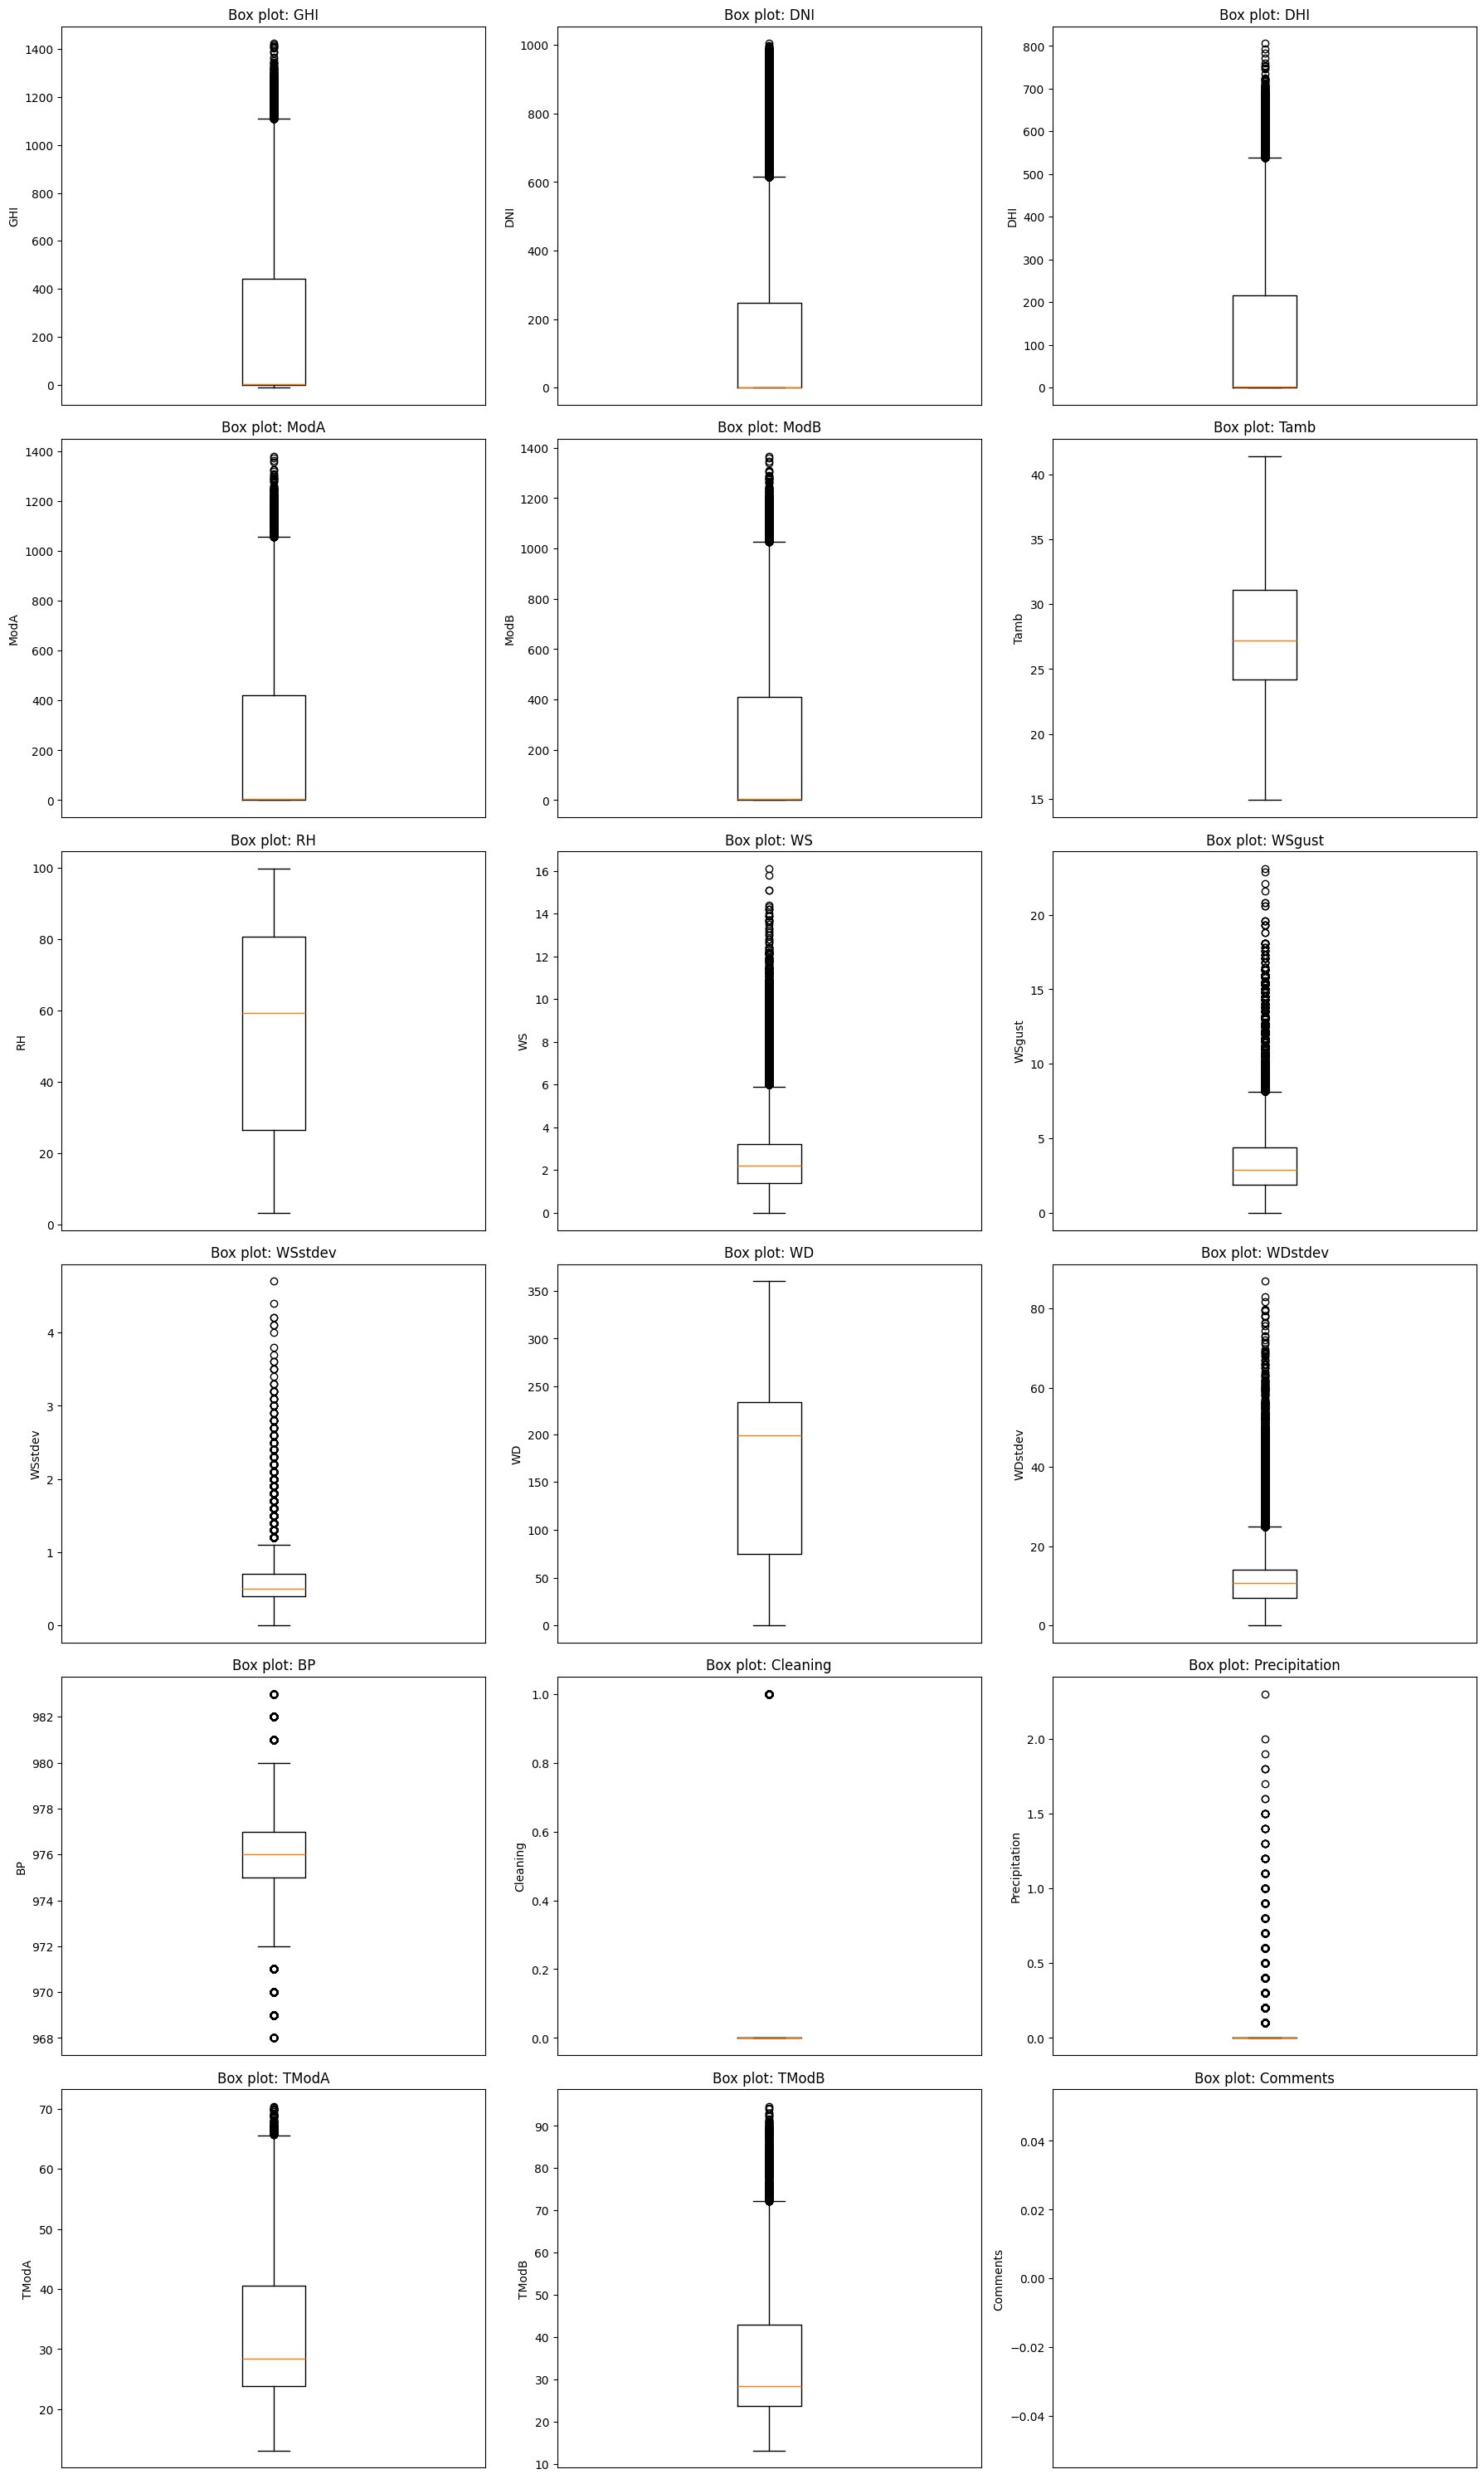

In [60]:
# Create a new figure for the box plots with the same grid dimensions
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes_box = axes_box.flatten()

# Loop and plot each box plot onto its assigned axis
for i, c in enumerate(num_cols):
    ax = axes_box[i]
    
    # Plot the box plot directly onto the current axis (ax)
    ax.boxplot(df[c].dropna(), vert=True)
    
    ax.set_title(f"Box plot: {c}", fontsize=12)
    ax.set_ylabel(c, fontsize=10)
    ax.set_xticks([]) # Remove x-ticks since only one box is plotted per axis

# Hide any unused subplots in the box plot figure
for j in range(n_plots, n_rows * 3):
    axes_box[j].axis('off')

plt.tight_layout()
plt.show()

## Box Plot Analysis – Interpretation

### Irradiance (GHI, DNI, DHI)
- Boxplots show a clear day/night split: a large cluster of near‑zero (and slightly negative) readings at night and a long daytime tail.  
- Many points flagged as "outliers" are simply high daytime values, not necessarily sensor errors.  
- Suggestion: add a Day/Night flag (used elsewhere here as GHI > 10) and replot boxplots for daytime only.

### Module readings & module temps (ModA, ModB, TModA, TModB)
- ModA/ModB are effectively zero at night and show the daytime spikes expected from production.  
- TModA and TModB are almost identical (corr ≈ 0.98) — keeping both adds little information; consider using one or their average.  
- Suggestion: use module power only when irradiance is present (e.g., GHI > 10).

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- Wind speed and gusts show heavy upper tails and many spikes. Gust spikes may be real events or sensor noise.  
- Suggestion: inspect timestamps of large WSgust values before removing; consider capping/winsorizing or encoding gust events as flags.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Ambient temperature and RH behave sensibly (RH high at night, Tamb higher in daytime). Precipitation is mostly zero.  
- BP and Cleaning are narrow/stable.

### Flags, metadata, and housekeeping
- Comments column is entirely missing (100% null) and produced an empty boxplot — drop it from analysis.  
- No exact duplicate rows remain (duplicates = 0).

### Additional observations from the data
- Irradiance channels are strongly correlated (GHI↔DNI ≈ 0.89, GHI↔DHI ≈ 0.85) — using all three without care causes multicollinearity.  
- Outlier filtering and median imputation were already applied in later cells.

### Next steps
- Drop the Comments column.  
- Add a Day/Night flag (e.g., GHI > 10) and replot boxplots restricted to daytime.  
- Inspect timestamps for extreme WSgust values to decide if they are real; then cap or flag accordingly.  
- Consider reducing redundant features (remove one TMod sensor or average them; be mindful of correlated irradiance channels).


# 2. Outlier Detection & Basic Cleaning

In [62]:

# 1. Define key columns
key_cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]

# 2. Handle missing values (impute with median)
for col in key_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# 3. Outlier detection using Z-score (|Z| > 3)
z = np.abs(stats.zscore(df[key_cols], nan_policy="omit"))
outlier_mask = (z > 3).any(axis=1)
print(f"Rows flagged as outliers: {outlier_mask.sum()}")

# 4. Remove outliers
df_clean = df[~outlier_mask].copy()

# 5. Remove exact duplicates
df_clean = df_clean.drop_duplicates()

# 6. Export cleaned DataFrame
df_clean.to_csv("../data/togo_clean.csv", index=False)
print("Cleaned dataset saved to: ../data/togo_clean.csv")

Rows flagged as outliers: 9251
Cleaned dataset saved to: ../data/togo_clean.csv


# 3. Time Series Analysis

C:\Users\dell\AppData\Local\Temp\ipykernel_34252\3257358684.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

c:\BackUp\web-projects\tenx\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


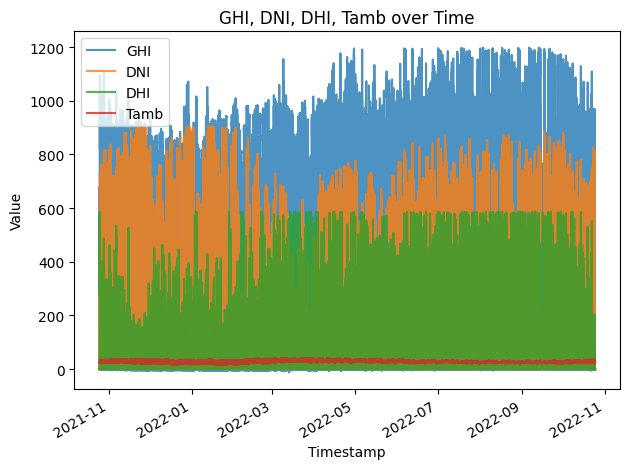

C:\Users\dell\AppData\Local\Temp\ipykernel_34252\3257358684.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()


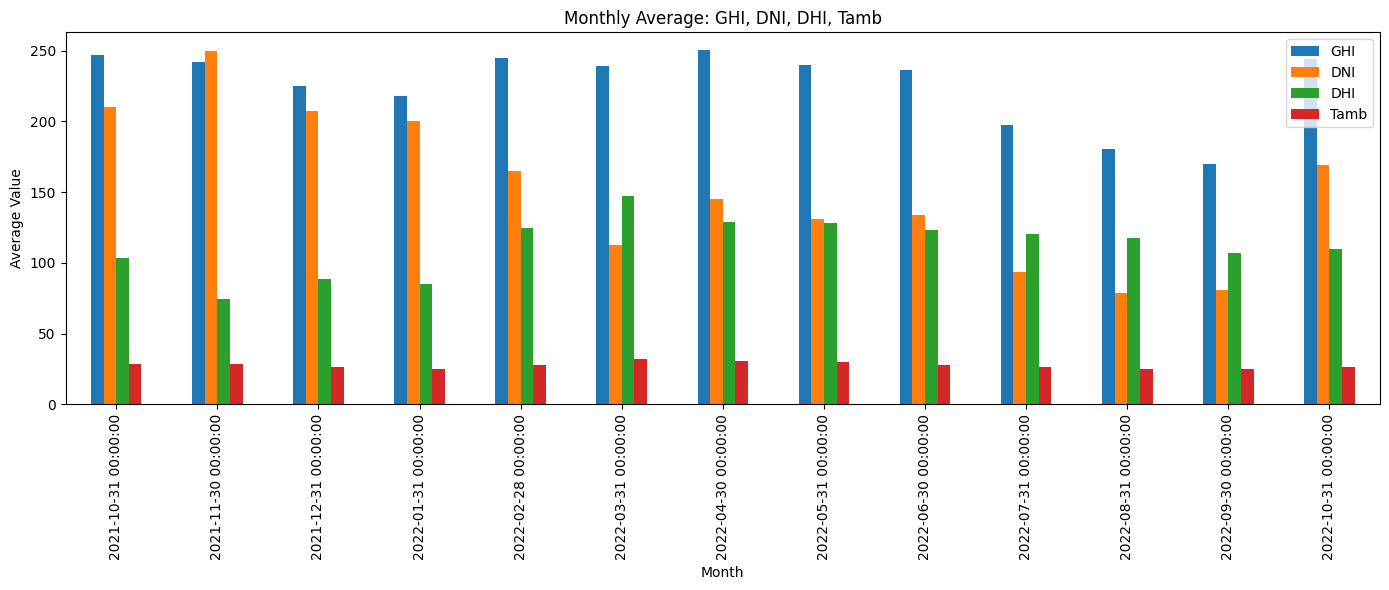

C:\Users\dell\AppData\Local\Temp\ipykernel_34252\3257358684.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()


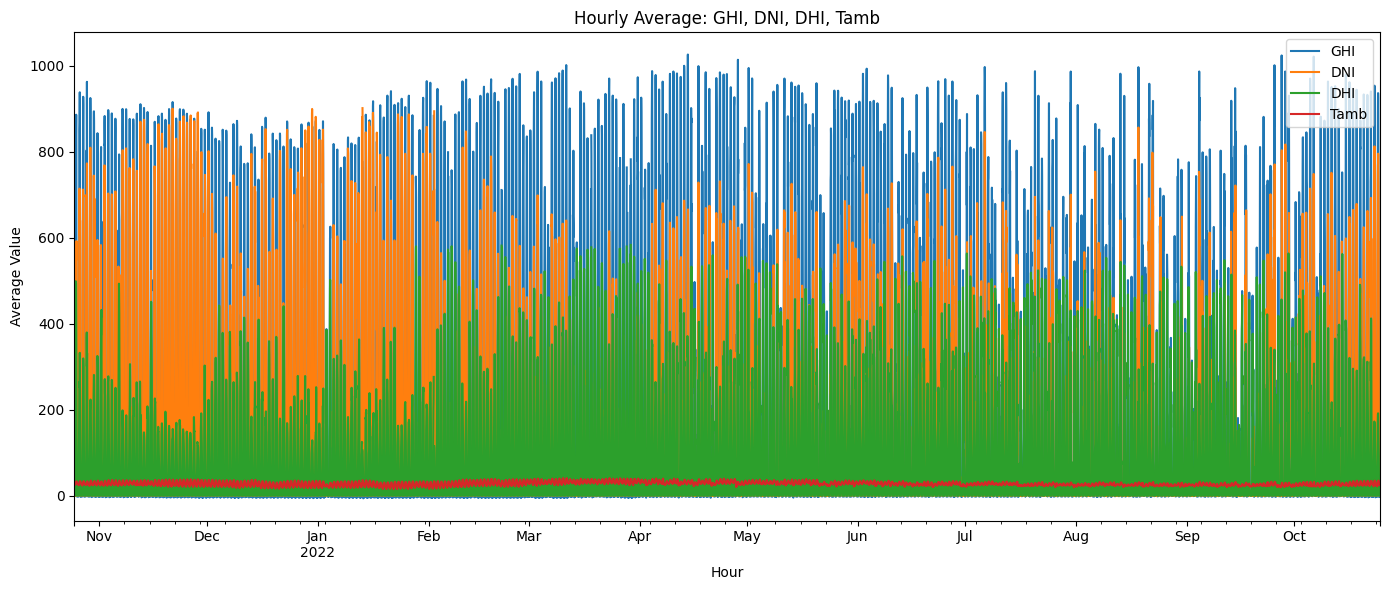

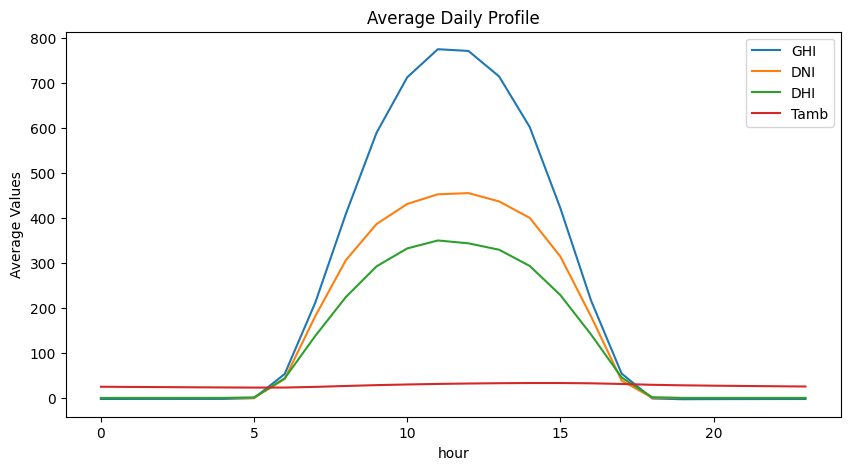

c:\BackUp\web-projects\tenx\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


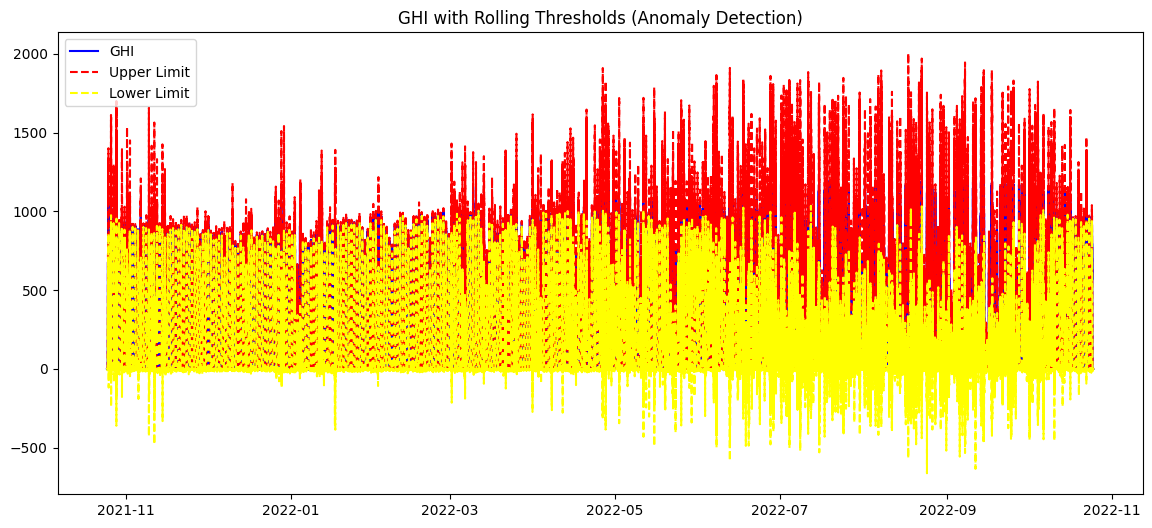

In [64]:
# Load cleaned data
df_clean = pd.read_csv("../data/togo_clean.csv")

# Ensure timestamp is in datetime format
df_clean["Timestamp"] = pd.to_datetime(df_clean["Timestamp"])

# Set timestamp as index for easier plotting
df_clean.set_index("Timestamp", inplace=True)

# Plot line charts for solar irradiance and temperature
plt.figure(figsize=(14, 6))
df_clean[["GHI", "DNI", "DHI", "Tamb"]].plot(alpha=0.8)
plt.title("GHI, DNI, DHI, Tamb over Time")
plt.ylabel("Value")
plt.xlabel("Timestamp")
plt.legend()
plt.tight_layout()
plt.show()

# Monthly average bar chart
monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()
monthly_avg.plot(kind="bar", figsize=(14, 6))
plt.title("Monthly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

# Hourly average line chart (diurnal pattern)
hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()
hourly_avg.plot(figsize=(14, 6))
plt.title("Hourly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()

# Hourly average line chart() 
df_clean['hour'] = df_clean.index.hour
hourly_mean = df_clean.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

hourly_mean.plot(kind='line', figsize=(10, 5), title='Average Daily Profile')
plt.ylabel('Average Values')
plt.show()

#Anomaly visualization
win = 24
mean = df_clean["GHI"].rolling(win).mean()
std = df_clean["GHI"].rolling(win).std()
upper_bar = mean + 3 * std
lower_bar = mean - 3 * std

plt.figure(figsize=(14,6))
plt.plot(df_clean.index, df_clean['GHI'], label='GHI', color='blue')
plt.plot(df_clean.index, upper_bar, color='red', linestyle='--', label='Upper Limit')
plt.plot(df_clean.index, lower_bar, color='yellow', linestyle='--', label='Lower Limit')
plt.title('GHI with Rolling Thresholds (Anomaly Detection)')
plt.legend()
plt.show()

### 3. Time Series Analysis — summary

- Timestamp and data setup
    - Timestamps converted to datetime and set as the index to enable resampling and time-series plotting.
    - Data after cleaning: 516,349 rows (original raw df: 525,600 rows) — ~9,251 rows removed (~1.8%).

- Main pattern: day vs night
    - Strong day/night cycle: GHI/DNI/DHI are near zero at night and peak during daytime.
    - Day/night split is pronounced (night ≈ 46–47% of records). Treat night separately for production or performance models (example rule used: GHI > 10 = Day).

- Hourly and monthly behaviour
    - Hourly averages show a repeatable diurnal profile (clear peak around late morning / midday; hourly_mean peaks ~775 W/m² at 11–12).
    - Monthly averages capture seasonal variation (monthly_avg across 13 months available) — use month/season features where helpful.

- Data cleaning & anomaly detection
    - Median imputation + z‑score outlier removal was applied; rolling-window anomaly visualization used a 24-sample window (rolling mean ± 3·std) to flag unusual GHI events.
    - Cleaning events (physical panel cleaning) produce a large, consistent module output increase (see Cleaning impact below).

- Cleaning impact (physical maintenance)
    - Average ModA before cleaning ≈ 232.32 W/m², after cleaning ≈ 306.61 W/m²; ModB shows a similar uplift (~225.0 → 301.45 W/m²) — roughly +~74 W/m² gain attributable to cleaning.

- Quality issues to watch
    - WSgust and some wind columns contain many spikes — investigate timestamps to distinguish real events from sensor noise; consider capping or flagging gust events.
    - Comments column is 100% missing and can be dropped.

- Relationships and redundancy
    - Irradiance channels are highly correlated: GHI↔DNI ≈ 0.89, GHI↔DHI ≈ 0.85 — these channels largely move together and can introduce multicollinearity.
    - Module temperatures are almost identical: TModA↔TModB ≈ 0.98 — keep one sensor or use their average for modelling.

# 4. Cleaning Impact


Average Module Irradiance Pre/Post Cleaning
1 = Cleaning Occurred, 0 = No Cleaning
                ModA        ModB
Cleaning                        
0         219.217037  212.861920
1         528.864835  527.268498


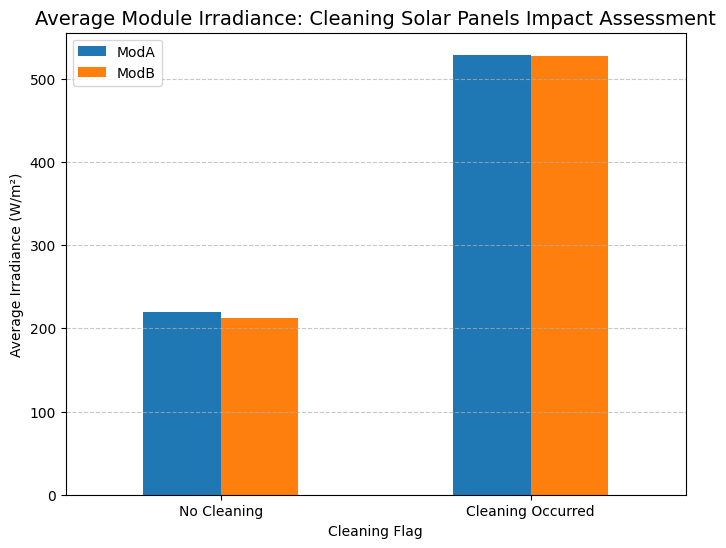

In [65]:
# Cleaning impact assessment
# in this case cleaning means removing dust from solar panels to improve efficiency not data cleaning
# there is a 'Cleaning' column  that exists with 1 for cleaning event and 0 otherwise
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage Module Irradiance Pre/Post Cleaning")
print("1 = Cleaning Occurred, 0 = No Cleaning")
print(cleaning_impact)

# Plotting the impact
plt.figure(figsize=(8, 6))
cleaning_impact.plot(kind='bar', ax=plt.gca())

plt.title('Average Module Irradiance: Cleaning Solar Panels Impact Assessment', fontsize=14)
plt.ylabel('Average Irradiance (W/m²)')
plt.xlabel('Cleaning Flag')
plt.xticks([0, 1], ['No Cleaning', 'Cleaning Occurred'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Cleaning impact — summary (updated)

- Average module irradiance when Cleaning = 0 (no cleaning): ModA ≈ 219.22 W/m², ModB ≈ 212.86 W/m² (mean ≈ 216.04 W/m²).

- Average module irradiance when Cleaning = 1 (cleaning occurred): ModA ≈ 528.86 W/m², ModB ≈ 527.27 W/m² (mean ≈ 528.07 W/m²).

- Observed change: a large increase of ≈ 312.03 W/m² after cleaning (≈ +144% relative increase vs. the pre‑cleaning mean).

- Action items / caveats
    - The jump is unusually large; verify sample sizes and date ranges for Cleaning = 0 vs 1 to ensure you are comparing comparable periods.
    - Inspect timestamps around cleaning events, look for sensor recalibration or metadata changes, and check for outliers or aggregation differences that could inflate the post‑cleaning mean.
    - If validated, this confirms maintenance has a very strong positive impact. If not, treat the result as a data/annotation issue to resolve before operational conclusions.

- Housekeeping
    - The Comments column is 100% missing and can be dropped from analysis.


# 5. Correlation & Relationship Analysis

### Correlation MAtrix

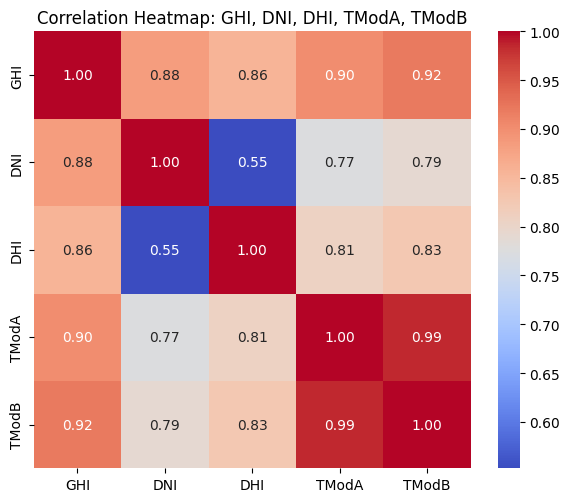

In [66]:
# 1. Correlation heatmap for selected columns
corr_cols = ["GHI", "DNI", "DHI", "TModA", "TModB"]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap: GHI, DNI, DHI, TModA, TModB")
plt.tight_layout()
plt.show()



### Wind vs. Solar Irradiance (WS, WSgust, WD vs. GHI)


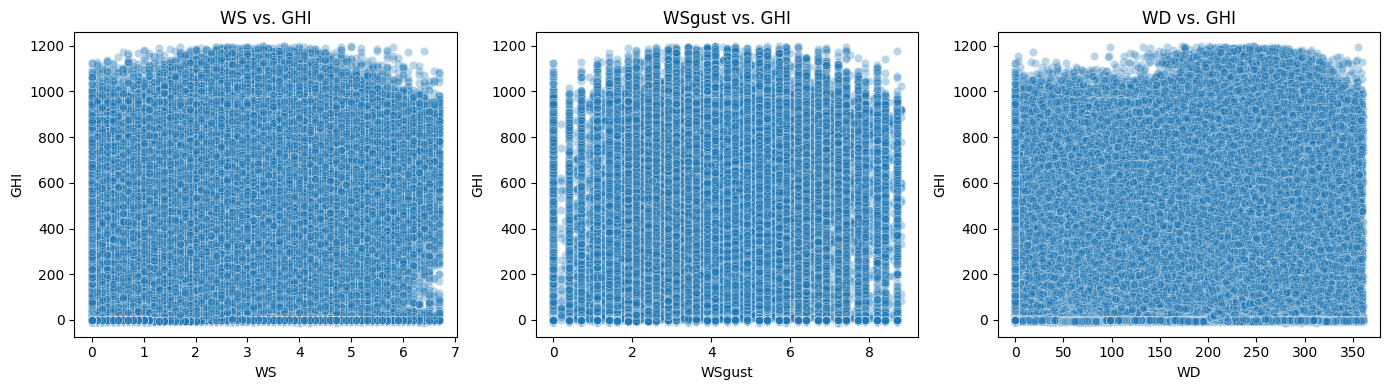

In [67]:
# 2. Scatter plots: wind variables vs. GHI
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x="WS", y="GHI", alpha=0.3)
plt.title("WS vs. GHI")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x="WSgust", y="GHI", alpha=0.3)
plt.title("WSgust vs. GHI")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x="WD", y="GHI", alpha=0.3)
plt.title("WD vs. GHI")

plt.tight_layout()
plt.show()

### Humidity vs. Temperature/Radiation (RH vs. Tamb or GHI)


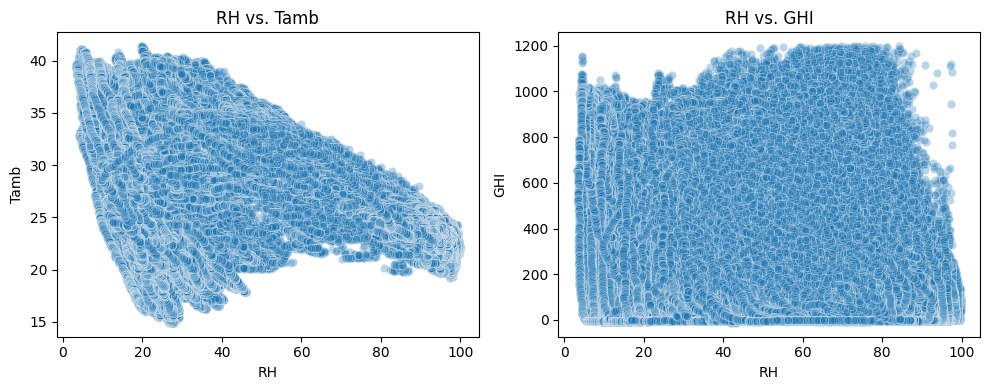

In [68]:
# 3. Scatter plots: RH vs. Tamb and RH vs. GHI
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb", alpha=0.3)
plt.title("RH vs. Tamb")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x="RH", y="GHI", alpha=0.3)
plt.title("RH vs. GHI")

plt.tight_layout()
plt.show()

###  Correlation & Relationship Analysis — summary

- Key numeric correlations (Pearson)
    - Correlation measures how two numbers move together (from -1 to 1). Numbers near 1 mean they move up and down together.
    - GHI ↔ DNI: 0.89 — very strong (they track each other closely).
    - GHI ↔ DHI: 0.85 — strong.
    - DNI ↔ DHI: 0.57 — moderate.
    - TModA ↔ TModB: 0.98 — almost identical readings.
    - Module temps ↔ irradiance (TModA/TModB vs GHI/DNI/DHI): high (≈0.8–0.92) — when sun increases, module temps increase.

- What this means
    - The three sunlight measurements are not independent — they mostly tell the same story. Using all three without care is redundant.
    - The two module temperature sensors give nearly the same value. Keeping both usually doesn’t add useful information.
    - Wind numbers (speed, gust, direction) do not show a clear, simple link to solar values in the plots. Gusts look spiky and event-driven.
    - Humidity and ambient temperature behave as expected: when temperature goes up, relative humidity tends to go down.

Section summaries
- Correlation matrix
    - Shows strong couplings: GHI–DNI–DHI and module temps all correlate highly (risk of multicollinearity).
    - Use dimensionality reduction or drop highly redundant features (e.g., keep GHI and one DHI/DNI component, average or drop one TMod).
    - Correlations are consistent with physical expectations (irradiance drives module temperature).

- Wind vs. Solar Irradiance (WS, WSgust, WD vs. GHI)
    - Scatter plots show no clear linear relationship between wind metrics and irradiance — wind is largely independent of sunlight level.
    - WSgust contains episodic spikes; investigate those timestamps before treating them as measurement errors or real events.
    - For modelling, treat wind features as separate drivers (possible interaction terms) rather than proxies for irradiance.

- Humidity vs. Temperature/Radiation (RH vs. Tamb or GHI)
    - RH is inversely related to Tamb and generally lower during high-GHI daytime — physically expected.
    - RH vs. GHI shows night cluster (high RH, GHI≈0) and daytime spread (lower RH, higher Tamb).
    - RH is useful as a control variable (affects module cooling/heating) but does not replace irradiance as the main driver of module temperature.


# 6 . Wind & Distribution Analysis


<Figure size 800x800 with 0 Axes>

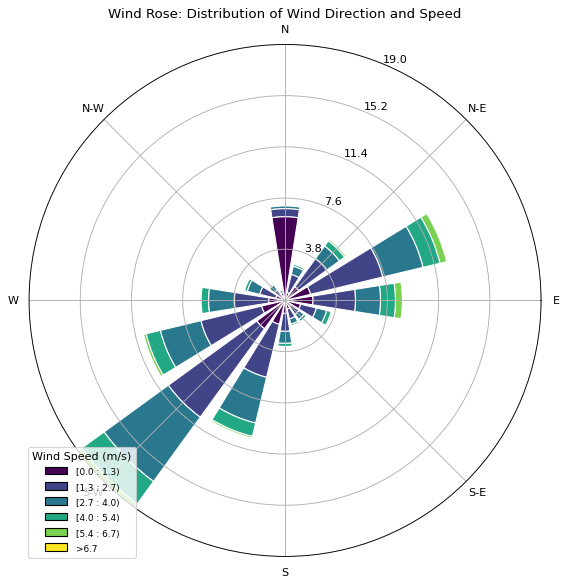

In [69]:
# Wind rose (radial bar plot) for WS and WD
plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose: Distribution of Wind Direction and Speed')
ax.set_legend(title='Wind Speed (m/s)')
plt.show()

### Histograms for GHI and WS

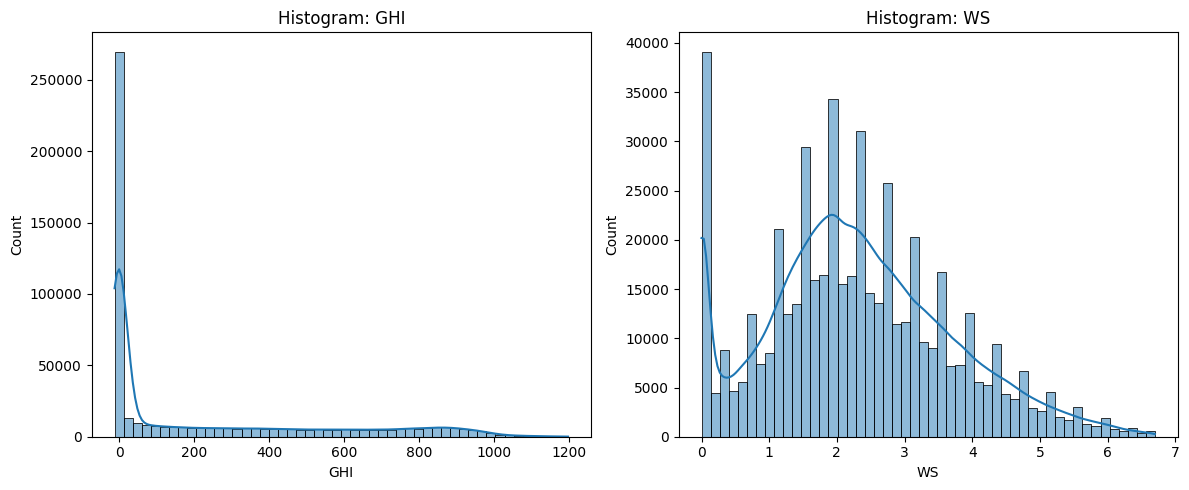

In [70]:
# Histograms for GHI and WS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean["GHI"], bins=50, kde=True)
plt.title("Histogram: GHI")
plt.xlabel("GHI")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["WS"], bins=50, kde=True)
plt.title("Histogram: WS")
plt.xlabel("WS")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Wind & Distribution Analysis — Summary

- Wind rose
    - Wind rose plotted: direction concentrated around east / southeast and those directions tend to show stronger wind speeds.
    - Use the wind rose to identify dominant wind sectors for any direction-dependent analysis.

- Wind direction & speed shape
    - Wind speed distribution is heavily right‑skewed: many low/near‑calm values and occasional strong gusts.
    - Gusts are episodic — large spikes appear in WSgust while the bulk of WS remains low.

- Gusts and spikes
    - WSgust contains many sudden spikes. Some correspond to real meteorological events, others may be sensor noise or logging artifacts — verify by inspecting timestamps around extremes.
    - For modelling, consider capping/winsorizing gusts or adding binary/event flags for large gust episodes.

- Night/day context (GHI)
    - GHI is near‑zero for most nighttime records and has a long daytime right tail. Day/night structure dominates the distributions and must be accounted for in any analysis of panel performance or energy-related metrics.
    - Recommendation: separate daytime (e.g., GHI > 10) and nighttime when computing summaries or fitting models.

- Housekeeping
    - Comments column is 100% missing and can be dropped.
    - Use wind diagnostics (rose + time series of WSgust) to decide whether gust spikes are physically plausible or require cleaning.

### Histograms for GHI and WS

- GHI histogram
    - Shows a large peak at or near zero (nighttime) and a broad right tail for daytime irradiance values.
    - Day/night splitting (or plotting daytime only) makes the histogram more informative for solar performance analysis.
    - Consider using more bins or a log/quantile view for daytime values to better resolve the tail.

- WS histogram
    - Strongly skewed: a high concentration of low speeds and a thin tail of higher speeds/gusts.
    - KDE + histogram (bins=50) helps visualise the modal calm conditions and the rarity of strong winds.
    - Consider trimming or winsorizing extreme WSgust values when computing summary statistics, or model them separately as events.


# 7 . Temperature Analysis

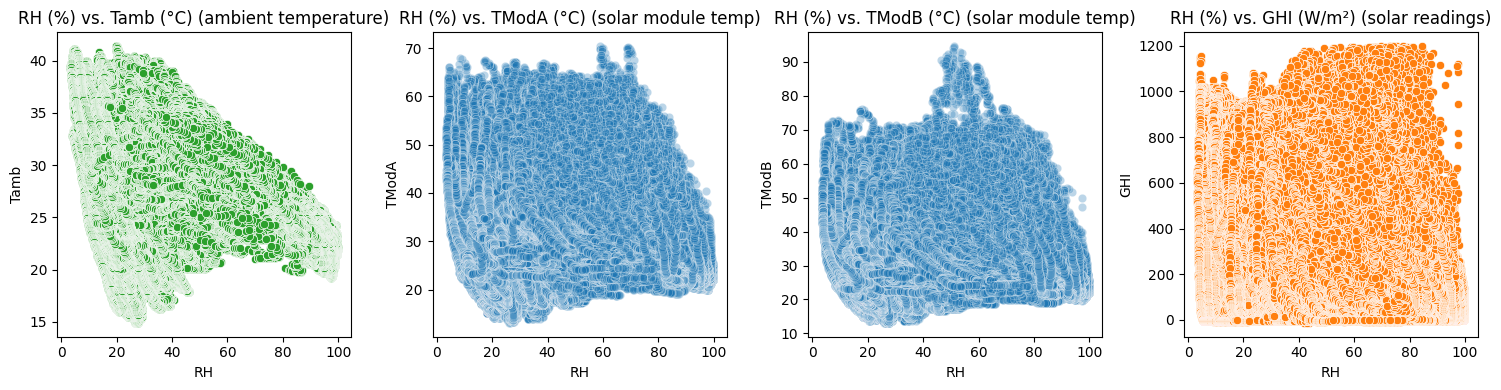

In [71]:
# Scatter plots: RH vs. temperature and solar radiation
plt.figure(figsize=(15, 4))
# Ambient temperature
plt.subplot(1, 4, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb",  color="tab:green")
plt.title("RH (%) vs. Tamb (°C) (ambient temperature)")
# Module temperatures
plt.subplot(1, 4, 2)
sns.scatterplot(data=df_clean, x="RH", y="TModA", alpha=0.3)
plt.title("RH (%) vs. TModA (°C) (solar module temp)")

plt.subplot(1, 4, 3)
sns.scatterplot(data=df_clean, x="RH", y="TModB", alpha=0.3)
plt.title("RH (%) vs. TModB (°C) (solar module temp)")
# Solar radiation
plt.subplot(1, 4, 4)
sns.scatterplot(data=df_clean, x="RH", y="GHI", color="tab:orange")
plt.title("RH (%) vs. GHI (W/m²) (solar readings)")

plt.tight_layout()
plt.show()

## 7. Temperature Analysis — Summary

- Key observations
    - RH vs Tamb: clear inverse relationship — higher Tamb (day) → lower RH; lower Tamb (night) → higher RH.
    - Module temps vs drivers:
        - TModA ↔ TModB: 0.985 (almost identical sensors).
        - TModA ↔ GHI: 0.90, TModB ↔ GHI: 0.92 — module temperatures track solar irradiance more strongly than ambient air.
    - Diurnal/monthly context:
        - Hourly averages show GHI peaks around 11–12 (~775 W/m²) and Tamb peaks in the early afternoon (~33 °C).
        - Monthly average Tamb is roughly in the 25–33 °C range (seasonal variation visible).
    - Data quality:
        - No missing values for Tamb, TModA, TModB in df_clean.
        - Comments column is 100% missing and can be dropped.

- Interpretation / practical notes
    - RH falls when Tamb rises because warmer air holds more moisture; for fixed absolute moisture, relative humidity decreases as temperature increases.
    - Sunlight (GHI) is the primary driver of module heating; ambient temperature is secondary.
    - Because TModA and TModB are highly redundant (corr ≈ 0.985), consider using one sensor or their average for modelling.
    - When analysing panel performance, separate daytime records (e.g., GHI > 10) from night to avoid mixing fundamentally different regimes.


# 8 . Bubble Chart

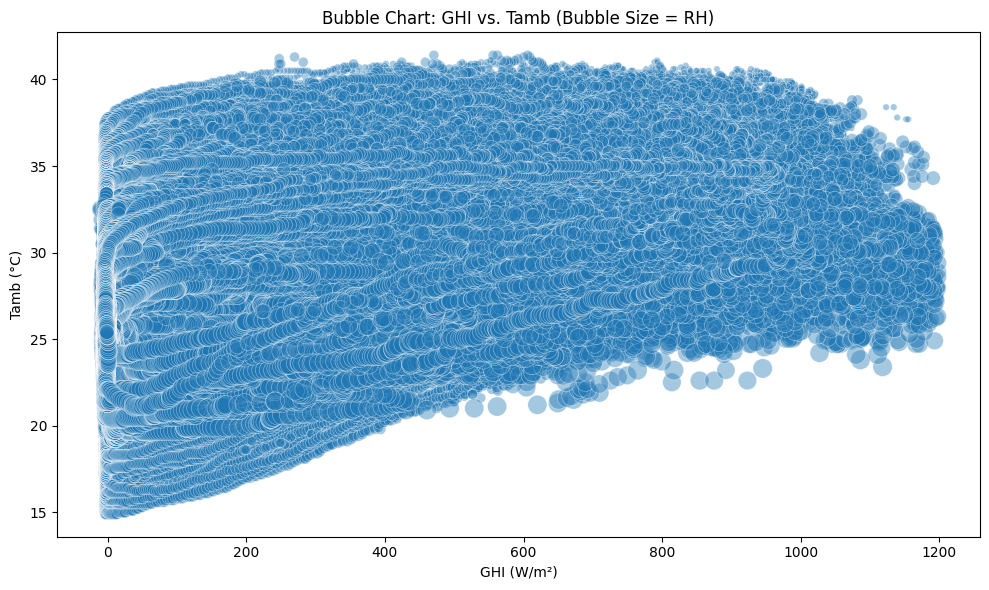

In [72]:

plt.figure(figsize=(10, 6))
bubble_size = df_clean["RH"]  # or use "BP" for bubble size

sns.scatterplot(
    data=df_clean,
    x="GHI",
    y="Tamb",
    size=bubble_size,
    sizes=(20, 200),
    alpha=0.4,
    legend=False
)
plt.title("Bubble Chart: GHI vs. Tamb (Bubble Size = RH)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Tamb (°C)")
plt.tight_layout()
plt.show()

## 8. Bubble Chart — Summary

- Purpose  
    Visualise the relationship between solar irradiance (GHI) and ambient temperature (Tamb), with bubble size encoding relative humidity (RH).

- Key observations  
    - Clear positive relationship: higher GHI generally corresponds to higher Tamb (diurnal heating).  
    - RH range in the dataset is roughly 52.3% → 94.5% (bubble_size Series min ≈ 52.3, max ≈ 94.5), so size differences are present but relatively subtle.  
    - A large cluster of points at GHI ≈ 0 represents nighttime records (GHI near‑zero). Day records are defined elsewhere as GHI > 10.  
    - Nighttime points tend to have larger RH (bigger bubbles); daytime points show smaller RH (smaller bubbles), consistent with expected inverse RH–temperature behavior.

- Summary  
    - X = GHI (W/m²), Y = Tamb (°C), bubble size = RH (%).  
    - Most night records cluster at GHI ≈ 0; daytime shows the expected upward trend in Tamb with GHI.  
    - Bubble-size differences confirm humidity is higher at night but vary in a relatively narrow band.

- Takeaway  
    - The plot reinforces a simple physical relationship: sunlight → warmer air.  
    - For panel‑performance or production analysis, restrict or stratify to daytime data (e.g., GHI > 10) to avoid mixing fundamentally different regimes.


## Multivariate Analysis

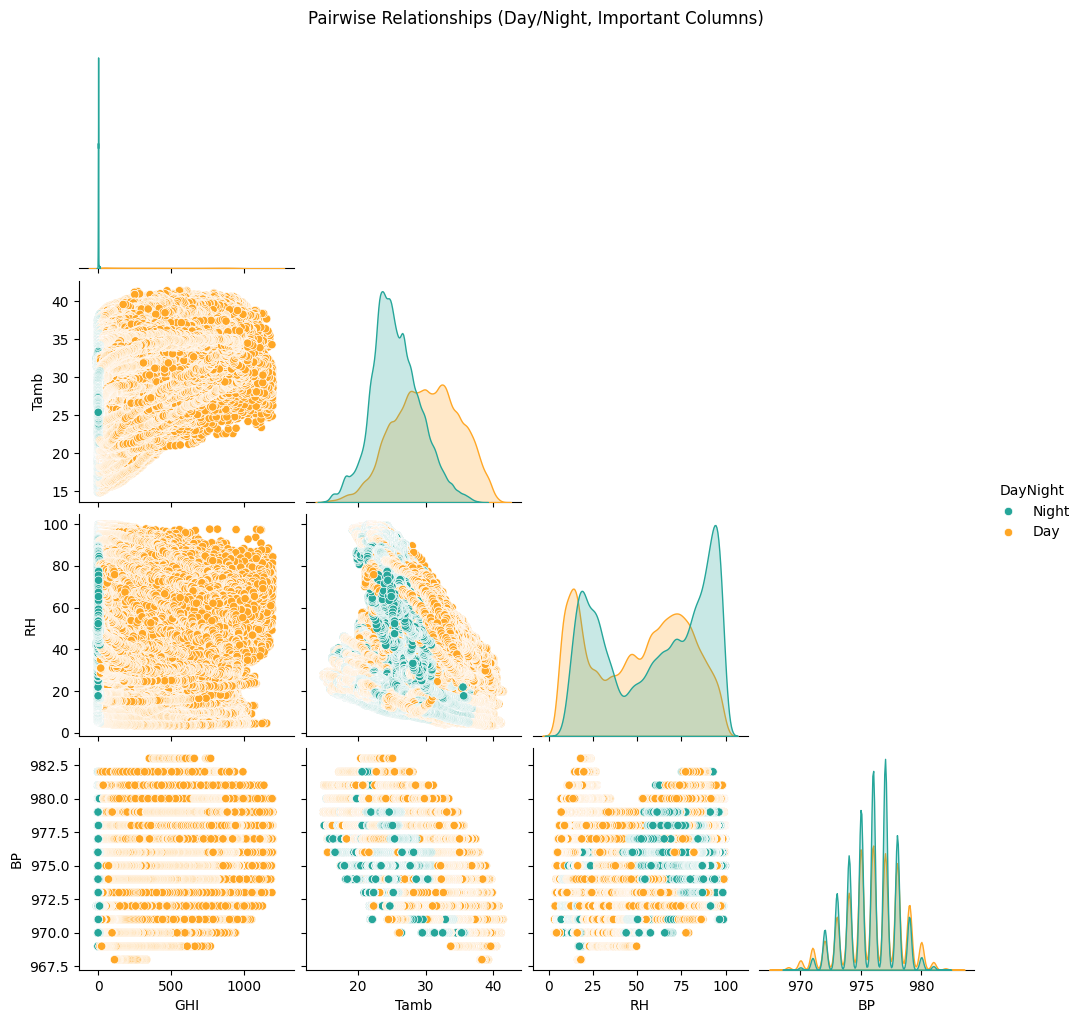

In [73]:
# Pairplot (quick overview)
# Ensure DayNight column exists (e.g., GHI > 10 is day)
df_clean["DayNight"] = np.where(df_clean["GHI"] > 10, "Day", "Night")

# Select important columns only
pairplot_cols = ["GHI", "Tamb", "RH", "BP", "DayNight"]

sns.pairplot(df_clean[pairplot_cols], hue="DayNight", corner=True,
             palette={"Day": "#FFA726", "Night": "#26A69A"})
plt.suptitle("Pairwise Relationships (Day/Night, Important Columns)", y=1.02)
plt.show()


## Multivariate Analysis — Summary

- Data & scope
    - Analysis run on df_clean (516,349 rows). Pairplot used: GHI, Tamb, RH, BP, DayNight (Day if GHI > 10).
    - Strong day/night separation (GHI ≈ 0 cluster for night; day/night grouping is visually clear).

- Key correlations (Pearson)
    - GHI ↔ DNI: 0.88 (strong)
    - GHI ↔ DHI: 0.86 (strong)
    - TModA ↔ TModB: 0.99 (very strong)
    - Module temps ↔ GHI: TModA ≈ 0.90, TModB ≈ 0.92 (module temperature closely tracks irradiance)

- Interpretations
    - High multicollinearity among irradiance channels (GHI, DNI, DHI) and between module temperature sensors — many features are redundant; consider dropping or combining redundant variables (e.g., keep GHI, drop/transform DNI/DHI; average or select one TMod).
    - Pairwise plots (GHI, Tamb, RH) show physically consistent relationships: GHI positively related to Tamb, RH inversely related to Tamb, and clear day/night clusters when colored by DayNight.
    - Wind variables (WS, WSgust, WD) show weak or unclear relationships with irradiance in scatter plots; gusts are episodic/spiky and should be treated as event-driven (inspect timestamps, consider capping/winsorizing or creating gust-event flags).
    - Housekeeping: Comments column is 100% missing and can be dropped.